

## Summary of Findings

**Key finding:** CES score from the personal verification flow is a statistically significant predictor of follow-on transfer frequency across all platforms. After controlling for country and platform, each 1-point CES increase is associated with **7.9% more follow-on transfers** (negative binomial regression, p<0.0001). This is the strongest and most consistent behavioral signal in the data.

### What CES predicts well:
- **Follow-on transfer count** — significant across all platforms (Kruskal-Wallis: Android p=0.002, iOS p=0.008, Web p<0.0001). Top-3-box users make more repeat transfers than bottom-box users.
- **Conversion to first transfer (mobile only)** — Android (p=0.0005) and iOS (p=0.0002) show a ~5-8pp conversion lift for higher CES users. Web shows no significant relationship.

### What CES does not predict:
- **Transfer value** — no meaningful relationship on mobile. Web shows significance but this may be driven by a few high-value outliers.
- **First transfer amount** — no pattern, which is actually useful: it confirms CES measures verification friction, not user wealth/intent.
- **Time to first transfer** — counterintuitively, lower-CES users transfer *faster*, likely reflecting a motivation bias (urgent users push through friction but are unhappy about it).

In [1]:
#load the data, do initial cleaning and feature engineering, load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import sys
sys.path.insert(0, '/Users/bryan.carroll/Library/CloudStorage/GoogleDrive-bryan.carroll@wise.com/My Drive/BryWise/AI')
import wise_colours  # type: ignore[import-unresolved]

# Load the data
full_data = pd.read_csv('ces_transactions3.csv')



# Time to first transfer in hours
full_data['time_to_first_transfer'] = (pd.to_datetime(full_data['FIRST_TRANSFER_DATE']) - pd.to_datetime(full_data['SURVEY_DATE'])) / pd.Timedelta(days=1)

df = full_data.copy()

# Remove rows where time to first transfer is negative
df = df[df['time_to_first_transfer'] >= 0]

df['FIRST_TRANSFER_MONTH'] = pd.to_datetime(df['FIRST_TRANSFER_DATE']).dt.to_period('M')
df['SEND_MONTH'] = pd.to_datetime(df['SEND_MONTH']).dt.to_period('M')
df['SURVEY_MONTH'] = pd.to_datetime(df['SURVEY_DATE']).dt.to_period('M')





### Important caveats:
1. **Causality is not established.** Users with inherently stronger intent to use Wise may both rate the experience higher and transact more. This analysis shows association, not that improving CES *causes* more transfers.
2. **Survivorship bias.** Users who rage-quit during verification never took the survey — the worst-experience users are missing from the data entirely.
3. **Perception-based measurement.** User motivations and mental models add noise to the CES signal. This data wasn't designed for this kind of longitudinal analysis; properly designed measurement systems would mitigate these issues.
4. **Top-3-box grouping** strengthens signals on mobile, suggesting the 7-point scale may have more granularity than the underlying construct warrants.

### Implication:
There is evidence of a downstream economic benefit to Wise from improving verification experiences (more repeat transactions), but properly designed experimentation and measurement systems with more data would be needed to quantify the true effect and isolate its drivers.

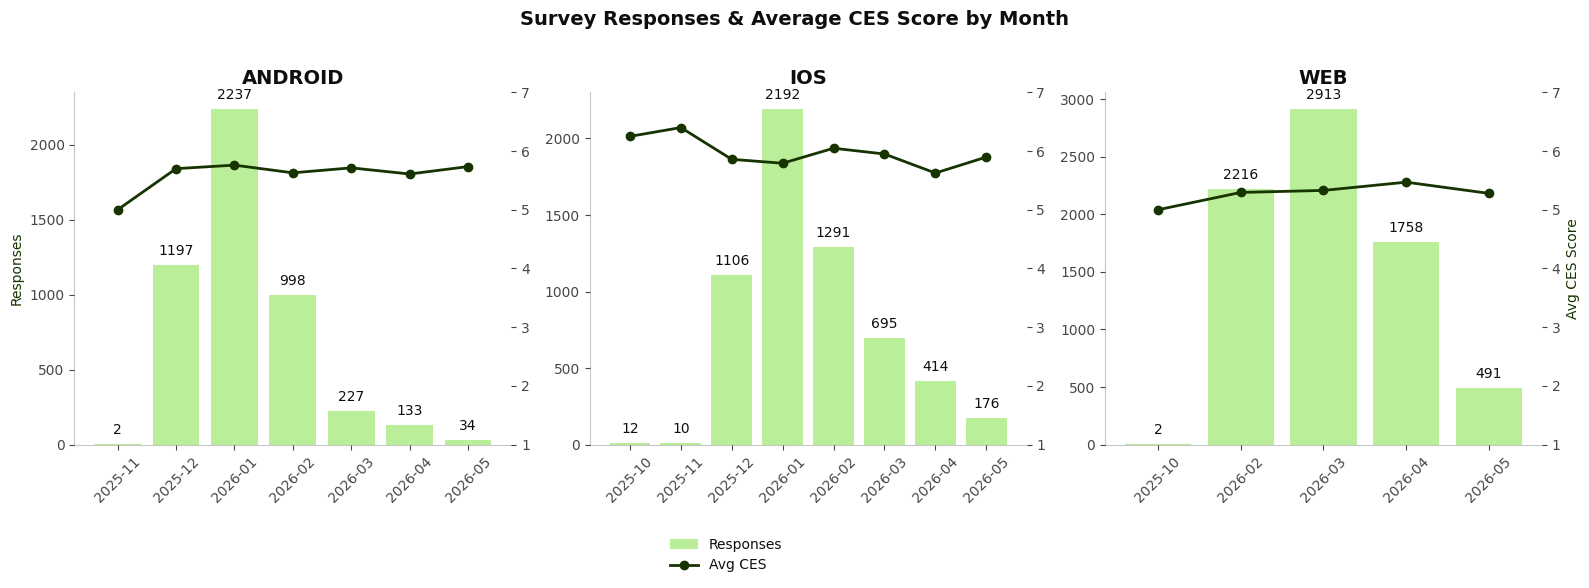

In [2]:
#show responses and average CES by month for each platform
platforms = ['ANDROID', 'IOS', 'WEB']
monthly = df[df['PLATFORM'].isin(platforms)].groupby(['PLATFORM', 'SURVEY_MONTH']).agg(
    responses=('CES_SCORE', 'count'),
    avg_ces=('CES_SCORE', 'mean')
).reset_index()
monthly['SURVEY_MONTH'] = monthly['SURVEY_MONTH'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for i, (ax, platform) in enumerate(zip(axes, platforms)):
    data = monthly[monthly['PLATFORM'] == platform]
    
    ax.bar(data['SURVEY_MONTH'], data['responses'], color=wise_colours.BRIGHT_GREEN, alpha=0.7, label='Responses')
    ax.set_xlabel('')
    ax.set_ylabel('Responses' if i == 0 else '', color=wise_colours.FOREST_GREEN)
    ax.set_title(platform)
    ax.tick_params(axis='x', rotation=45)
    
    ax2 = ax.twinx()
    ax2.plot(data['SURVEY_MONTH'], data['avg_ces'], color=wise_colours.FOREST_GREEN, marker='o', linewidth=2, label='Avg CES')
    ax2.set_ylim(1, 7)
    ax2.set_ylabel('Avg CES Score' if i == len(platforms) - 1 else '', color=wise_colours.FOREST_GREEN)

    for bar in ax.patches:
        ax.annotate(f"{bar.get_height():1}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

fig.suptitle('Survey Responses & Average CES Score by Month', fontsize=14, y=1.02)
handles1, labels1 = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[0].get_shared_x_axes().get_siblings(axes[0])[0].get_legend_handles_labels()  
fig.legend(handles1 + handles2, labels1 + labels2, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout()
plt.show()

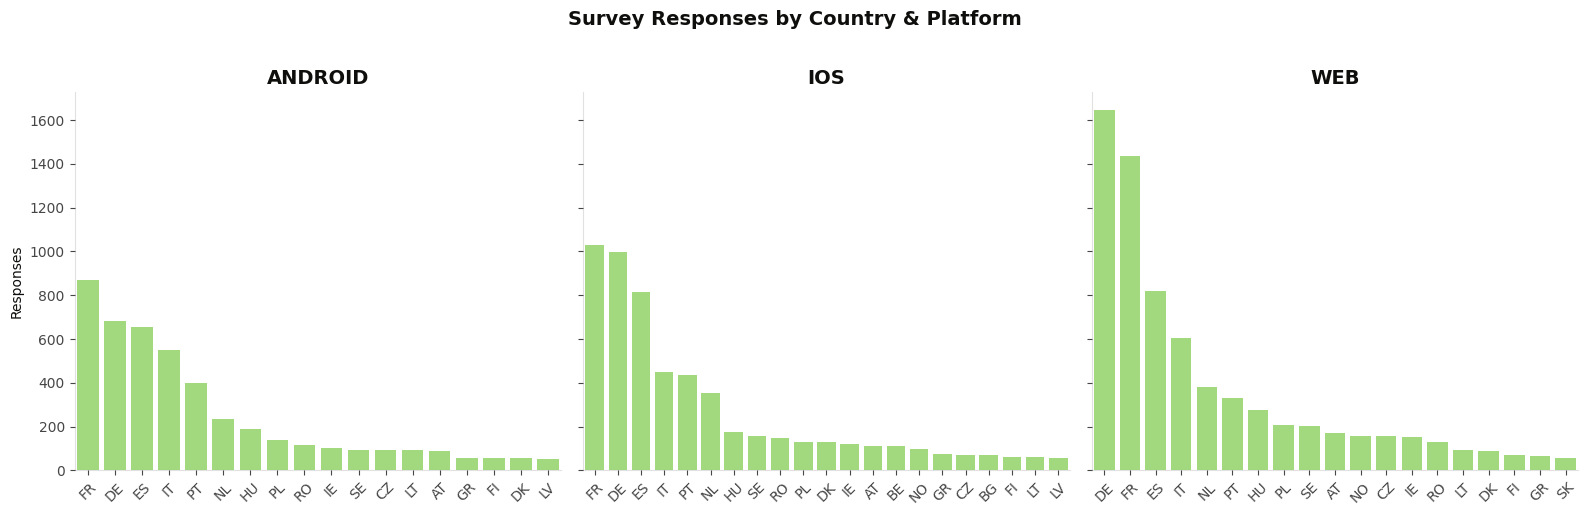

In [3]:
#survey responses by country and platform

country_platform = df[df['PLATFORM'].isin(platforms)].groupby(['REGISTRATION_COUNTRY', 'PLATFORM']).agg(
    responses=('CES_SCORE', 'count')).reset_index()

country_platform = country_platform[country_platform['responses'] > 50]
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = country_platform[country_platform['PLATFORM'] == platform].sort_values('responses', ascending=False)

    sns.barplot(x='REGISTRATION_COUNTRY', y='responses', data=data, ax=ax, order=data['REGISTRATION_COUNTRY'])
    ax.set_title(platform)
    ax.set_xlabel('')
    ax.set_ylabel('Responses' if platform == platforms[0] else '')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Survey Responses by Country & Platform', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

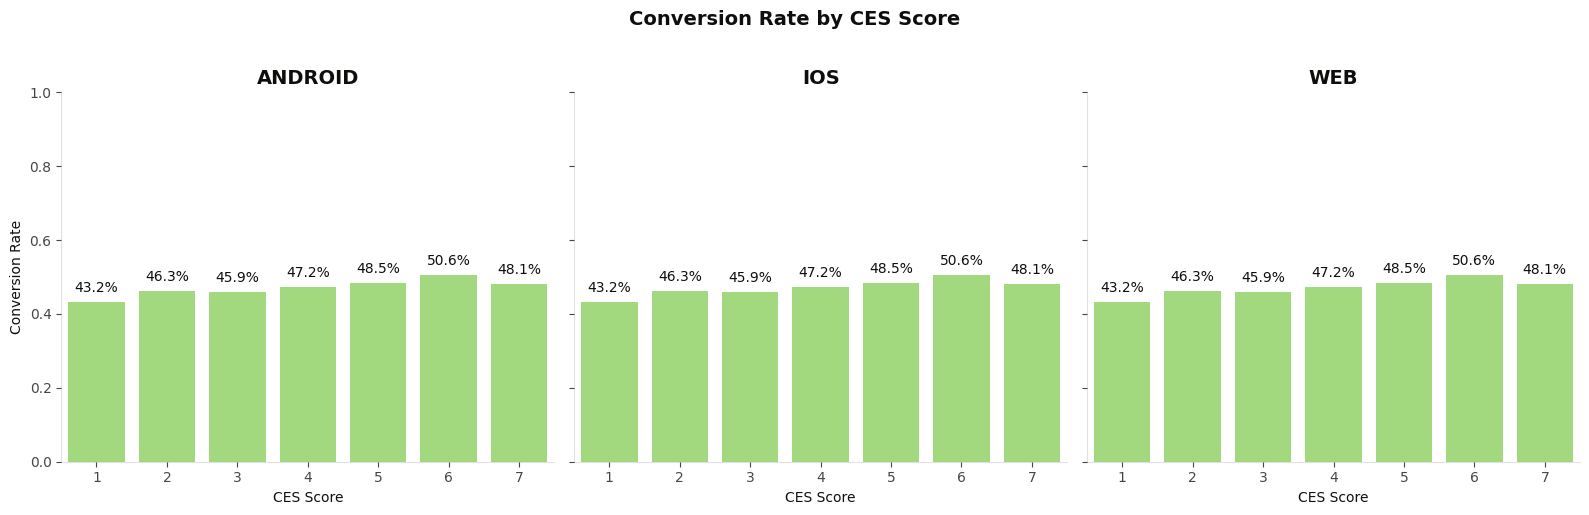

ANDROID: χ²=23.97, df=6, p=0.0005 ***
IOS: χ²=25.90, df=6, p=0.0002 ***
WEB: χ²=12.51, df=6, p=0.0516 ns


In [4]:
#understand if the conversion rate  changes based on CES score
full_data['converted'] = full_data['FIRST_TRANSFER_DATE'].notna()
platforms = ['ANDROID', 'IOS', 'WEB']

ces_conversion = full_data[full_data['PLATFORM'].isin(platforms)].groupby(['PLATFORM', 'CES_SCORE'])['converted'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = full_data[full_data['PLATFORM'].isin(platforms)].groupby(['PLATFORM', 'CES_SCORE'])['converted'].mean().reset_index()

    sns.barplot(x='CES_SCORE', y='converted', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, errorbar=None)
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('Conversion Rate' if ax == axes[0] else '')
    ax.set(ylim=(0, 1))

    for bar in ax.patches:
        ax.annotate(f"{bar.get_height():.1%}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

fig.suptitle('Conversion Rate by CES Score', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

#chi square test to see if there's a significant association between ces and conversion

platforms = ['ANDROID', 'IOS', 'WEB']
for platform in platforms:
    pdata = full_data[full_data['PLATFORM'] == platform]
    ct = pd.crosstab(pdata['CES_SCORE'], pdata['converted'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: χ²={chi2:.2f}, df={dof}, p={p:.4f} {sig}")

**Insight:** CES score is significantly associated with conversion on Android (p=0.0005) and iOS (p=0.0002), but not on Web (p=0.052). The effect is modest — conversion ranges from ~50% (low CES) to ~60% (high CES) on mobile, while Web is flat at ~35-40% regardless of score.

**Caveats:** This is correlational — users who had an easier experience may both rate higher AND be further along in onboarding. Survivorship bias is also possible: users who churned before completing verification aren't in the transfer data. Further, users who rage quit didn't complete onboarding and didn't take the survey, so this user group with the worst perception of Wise is not in the data.

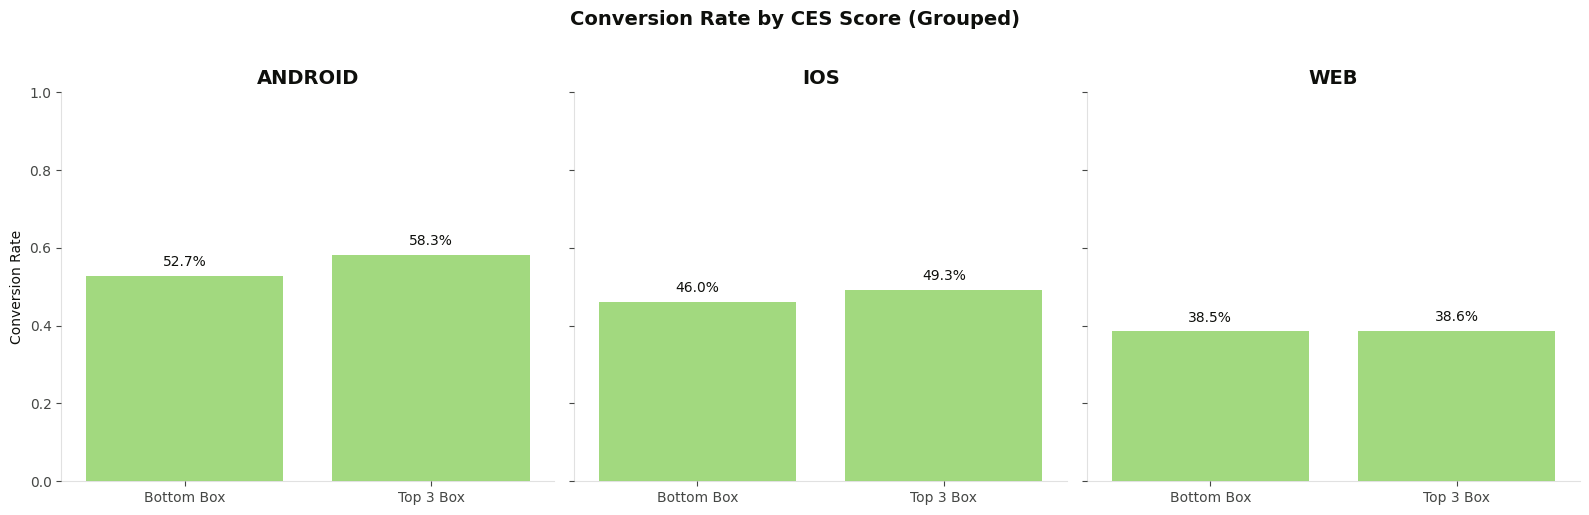

ANDROID: χ²=17.38, df=1, p=0.0000 ***
IOS: χ²=7.76, df=1, p=0.0054 **
WEB: χ²=0.01, df=1, p=0.9291 ns


In [5]:
#look at conversion rate by top 3 box instead of all ces scores, by platform

full_data['converted'] = full_data['FIRST_TRANSFER_DATE'].notna()
full_data['CES_TOP3'] = full_data['CES_SCORE'].apply(lambda x: 'Top 3 Box' if x >= 5 else ('Bottom Box' if x <= 4 else 'Middle'))
platforms = ['ANDROID', 'IOS', 'WEB']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = full_data[(full_data['PLATFORM'] == platform) & (full_data['CES_TOP3'] != 'Middle')].groupby('CES_TOP3')['converted'].mean().reset_index()

    sns.barplot(x='CES_TOP3', y='converted', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, errorbar=None)
    ax.set_title(platform)
    ax.set_xlabel('')
    ax.set_ylabel('Conversion Rate' if ax == axes[0] else '')
    ax.set(ylim=(0, 1))
    
    for bar in ax.patches:
        ax.annotate(f"{bar.get_height():.1%}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

fig.suptitle('Conversion Rate by CES Score (Grouped)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#chi square test to see if there's a significant association between ces and conversion
platforms = ['ANDROID', 'IOS', 'WEB']
for platform in platforms:
    pdata = full_data[(full_data['PLATFORM'] == platform) & (full_data['CES_TOP3'] != 'Middle')]
    ct = pd.crosstab(pdata['CES_TOP3'], pdata['converted'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: χ²={chi2:.2f}, df={dof}, p={p:.4f} {sig}")

**Insight:** The top-3-box grouping sharpens the mobile finding — Android (p<0.0001) and iOS (p=0.005) show significantly higher conversion for top-3-box vs bottom-box users. Web remains non-significant (p=0.93).

**Caveat:** The absolute difference is still small (~5-8pp on mobile). The signal is real but the practical magnitude may not justify major investment on its own. That the signal is strengthened with this grouping should lead us to consider whether reducing the granularity of the survey responses would lead to better measurement ability. 

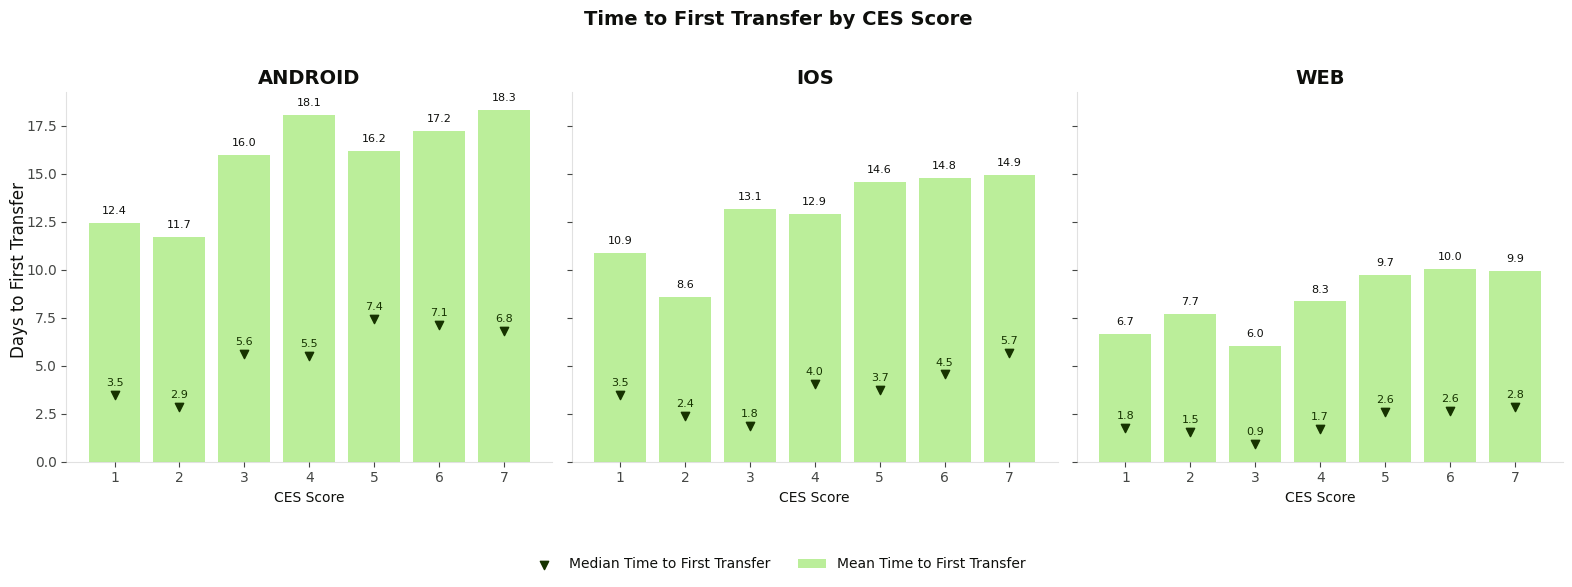

ANDROID: H=28.15, p=0.0001 ***
IOS: H=42.71, p=0.0000 ***
WEB: H=98.32, p=0.0000 ***


In [6]:
#now I want to see if there is an impact on time to first transfer from ces score

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, platform in zip(axes, platforms):
    data = df[df['PLATFORM'] == platform].groupby('CES_SCORE')['time_to_first_transfer'].agg(['mean', 'median']).reset_index()
    
    ax.bar(data['CES_SCORE'], data['mean'], color=wise_colours.BRIGHT_GREEN, alpha=0.7, label='Mean Time to First Transfer')
    ax.scatter(data['CES_SCORE'], data['median'], color=wise_colours.FOREST_GREEN, marker='v', zorder=3, label='Median Time to First Transfer')
    
    for _, row in data.iterrows():
        ax.annotate(f"{row['mean']:.1f}", (row['CES_SCORE'], row['mean']), ha='center', va='bottom', fontsize=8, xytext=(0, 5), textcoords='offset points')
        ax.annotate(f"{row['median']:.1f}", (row['CES_SCORE'], row['median']), ha='center', va='bottom', fontsize=8, color=wise_colours.FOREST_GREEN, xytext=(0, 5), textcoords='offset points')
    
    ax.set_xlabel('CES Score')
    ax.set_title(platform)
    ax.set_xticks(range(1, 8))

fig.suptitle('Time to First Transfer by CES Score', fontsize=14, y=1.02)
fig.supylabel('Days to First Transfer')
fig.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.show()

from scipy.stats import kruskal

for platform in platforms:
    pdata = df[df['PLATFORM'] == platform]
    groups = [group['time_to_first_transfer'].values for _, group in pdata.groupby('CES_SCORE')]
    stat, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: H={stat:.2f}, p={p:.4f} {sig}")

**Insight:** Lower CES users tend to transfer *faster*, the opposite of what we'd expect. This likely reflects a motivation bias: users with high urgency to send money pushed through a frustrating verification experience (hence low CES), but their strong intent meant they transferred quickly anyway.

The speed of first transfer may be a proxy for pre-existing urgency rather than a consequence of verification ease. The large mean/median gap also indicates heavy right-skew driven by a few slow converters. 

This demonstrates the difficulty in using a perception based metric; user motivations and mental models is an additional factor that muddies the signal. This analysis is using data that wasn't necessarily designed to measure things this way, properly designed and tested measurement systems can mitigate these problems.

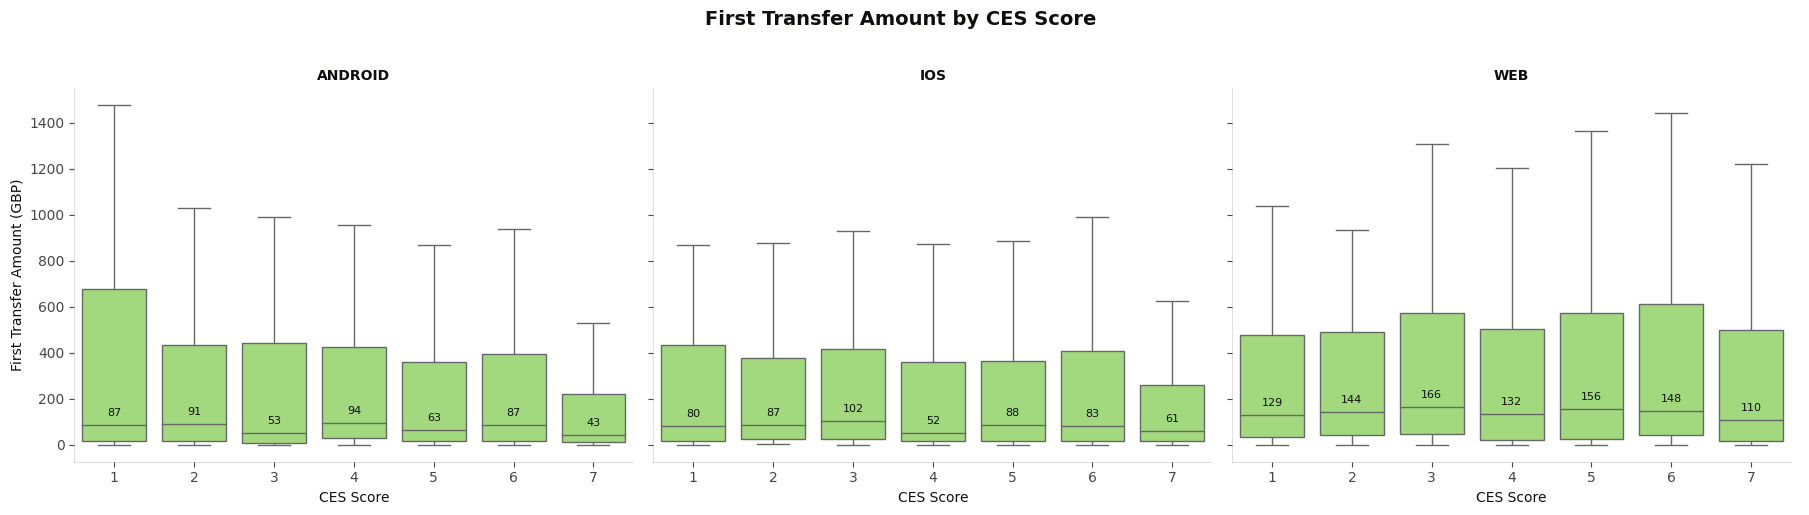

In [7]:
#boxplot showing first transfer amount by ces score and platform

g = sns.catplot(
    data=df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])],
    x='CES_SCORE', y='FIRST_TRANSFER_AMOUNT_GBP', col='PLATFORM',
    kind='box', showfliers=False, height=5, aspect=1.2, color=wise_colours.BRIGHT_GREEN
)
g.set_axis_labels('CES Score', 'First Transfer Amount (GBP)')
g.set_titles('{col_name}')
g.figure.suptitle('First Transfer Amount by CES Score', fontsize=14, y=1.02)

for ax in g.axes.flat:
    for i, box in enumerate(ax.get_xticks()):
        subset = df[(df['PLATFORM'] == ax.get_title()) & (df['CES_SCORE'] == i + 1)]['FIRST_TRANSFER_AMOUNT_GBP']
        if len(subset) > 0:
            median = subset.median()
            ax.annotate(f"{median:.0f}", (i, median), ha='center', va='bottom', fontsize=8, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Insight:** First transfer amounts are similar across CES scores — no meaningful pattern. This suggests that CES captures friction in the verification process, not differences in user wealth or intent to send a particular amount.

**Caveat:** Outliers are hidden (showfliers=False). First transfer amount is also a noisy proxy since users may be testing with a small send regardless of their actual use case, or meeting an urgent need with high motivation. 

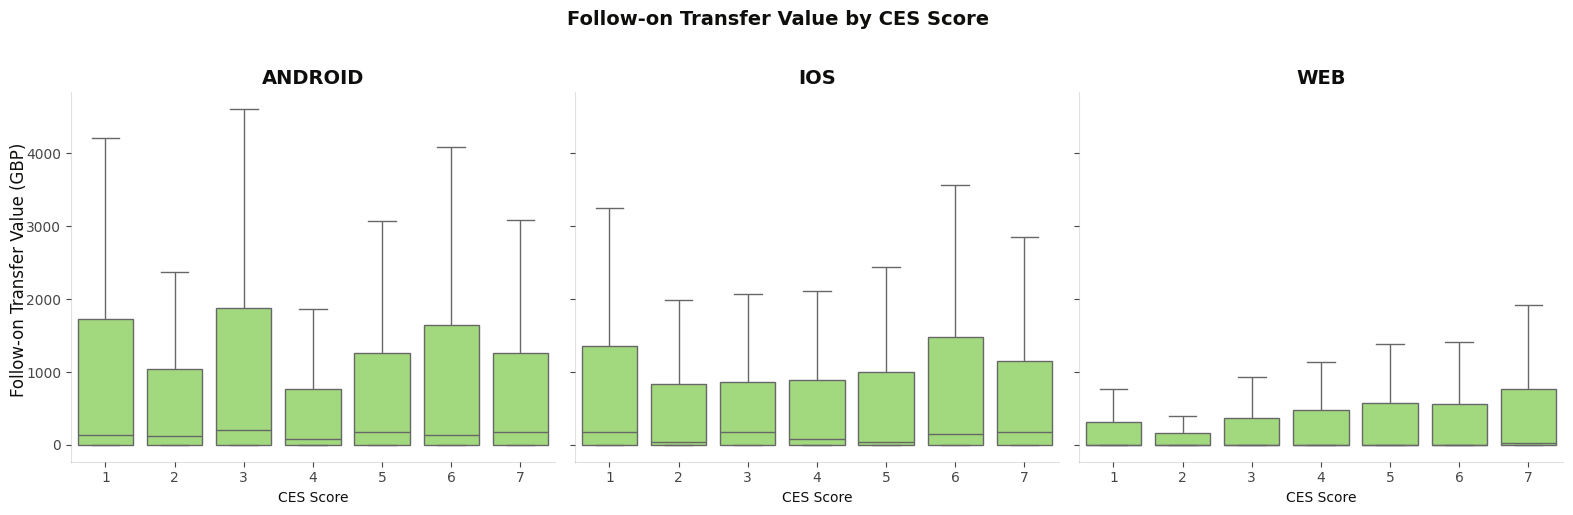

ANDROID: H=5.11, p=0.5298 ns
IOS: H=11.83, p=0.0659 ns
WEB: H=39.45, p=0.0000 ***


In [8]:
# Follow-on transfer value = total spend - first transfer amount
df_followon = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_SCORE', 'FIRST_TRANSFER_AMOUNT_GBP']
)['SEND_VALUE_GBP'].sum().reset_index()

df_followon['followon_value'] = df_followon['SEND_VALUE_GBP'] - df_followon['FIRST_TRANSFER_AMOUNT_GBP']

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = df_followon[df_followon['PLATFORM'] == platform]
    
    sns.boxplot(x='CES_SCORE', y='followon_value', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, showfliers=False)
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('')


fig.suptitle('Follow-on Transfer Value by CES Score', fontsize=14, y=1.02)
fig.supylabel('Follow-on Transfer Value (GBP)')
fig.tight_layout()
plt.show()

from scipy.stats import kruskal

for platform in platforms:
    data = df_followon[df_followon['PLATFORM'] == platform]
    groups = [group['followon_value'].values for _, group in data.groupby('CES_SCORE')]
    stat, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: H={stat:.2f}, p={p:.4f} {sig}")


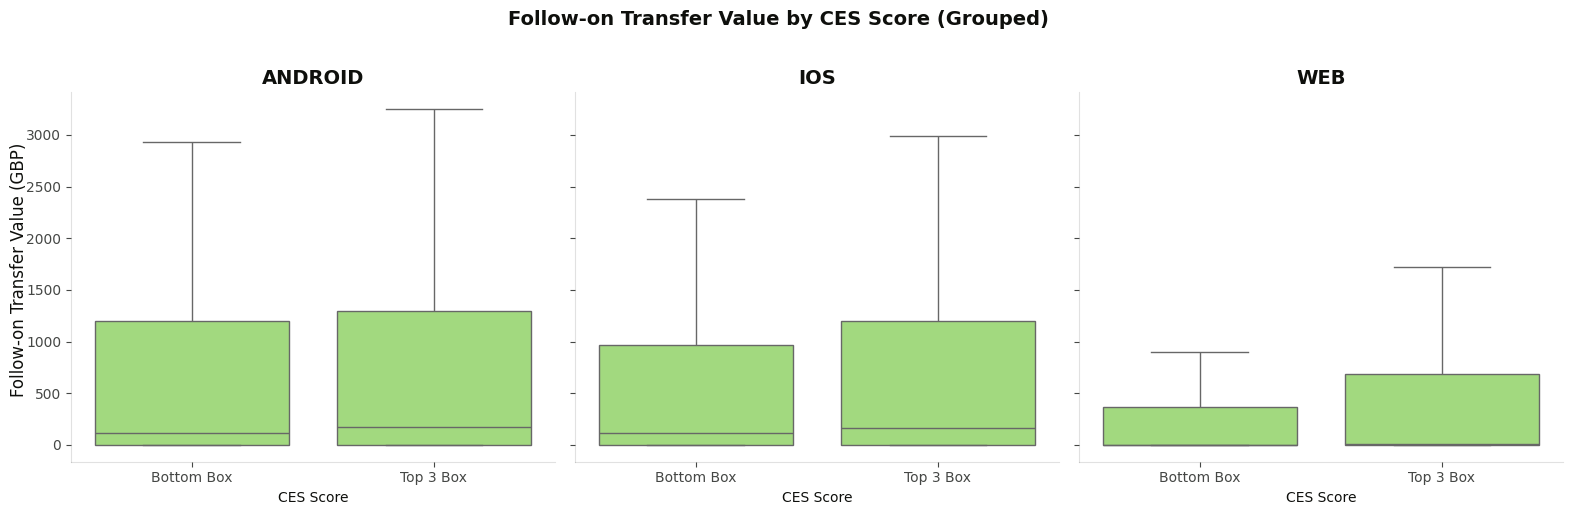

ANDROID: U=451626, p=0.0890 ns
IOS: U=696000, p=0.0871 ns
WEB: U=2761896, p=0.0000 ***


In [9]:
# Follow-on transfer value = total spend - first transfer amount by top 3 box
df['CES_TOP3'] = df['CES_SCORE'].apply(lambda x: 'Top 3 Box' if x >= 5 else ('Bottom Box' if x <=4 else 'Middle'))


df_followon = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_TOP3', 'FIRST_TRANSFER_AMOUNT_GBP']
)['SEND_VALUE_GBP'].sum().reset_index()

df_followon['followon_value'] = df_followon['SEND_VALUE_GBP'] - df_followon['FIRST_TRANSFER_AMOUNT_GBP']

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = df_followon[df_followon['PLATFORM'] == platform]
    
    sns.boxplot(x='CES_TOP3', y='followon_value', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, showfliers=False, order=['Bottom Box', 'Top 3 Box'])
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('')


fig.suptitle('Follow-on Transfer Value by CES Score (Grouped)', fontsize=14, y=1.02)
fig.supylabel('Follow-on Transfer Value (GBP)')
fig.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu

for platform in platforms:
    data = df_followon[df_followon['PLATFORM'] == platform]
    top3 = data[data['CES_TOP3'] == 'Top 3 Box']['followon_value']
    bottom_box = data[data['CES_TOP3'] == 'Bottom Box']['followon_value']
    stat, p = mannwhitneyu(top3, bottom_box, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: U={stat:.0f}, p={p:.4f} {sig}")


**Insight:** Follow-on transfer value does not differ significantly by CES score on mobile (Android p=0.53, iOS p=0.07). Only Web shows a significant difference (p<0.0001). When grouped into top/bottom box, a similar pattern holds — Web shows clear differentiation but mobile platforms do not.

**Caveat:** Transfer value is heavily skewed by a few high-value senders. The signal on Web may be driven by a small number of power users rather than a broad behavioral pattern.

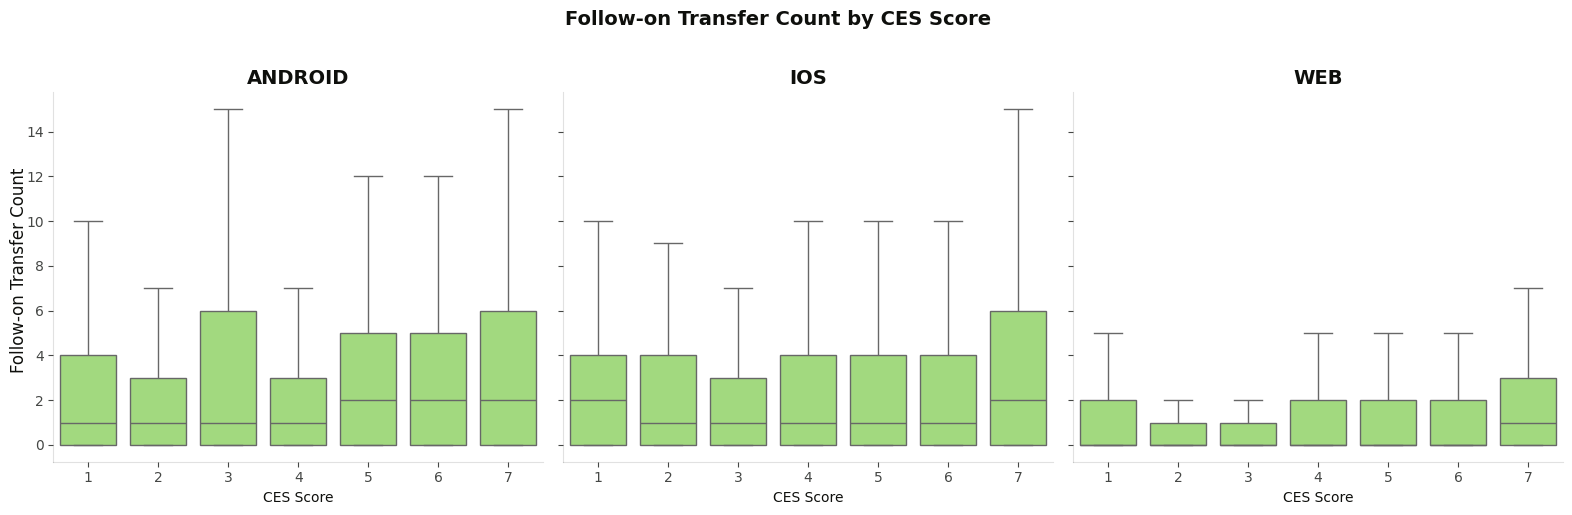

ANDROID: H=20.80, p=0.0020 **
IOS: H=17.44, p=0.0078 **
WEB: H=61.69, p=0.0000 ***


In [10]:
# Follow-on transfer count = total transfers - 1
df_followon = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_SCORE', 'FIRST_TRANSFER_AMOUNT_GBP']
)['SEND_COUNT'].sum().reset_index()

df_followon['followon_count'] = df_followon['SEND_COUNT'] - 1

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = df_followon[df_followon['PLATFORM'] == platform]
    
    sns.boxplot(x='CES_SCORE', y='followon_count', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, showfliers=False)
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('')


fig.suptitle('Follow-on Transfer Count by CES Score', fontsize=14, y=1.02)
fig.supylabel('Follow-on Transfer Count')
fig.tight_layout()
plt.show()

from scipy.stats import kruskal

for platform in platforms:
    data = df_followon[df_followon['PLATFORM'] == platform]
    groups = [group['followon_count'].values for _, group in data.groupby('CES_SCORE')]
    stat, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: H={stat:.2f}, p={p:.4f} {sig}")


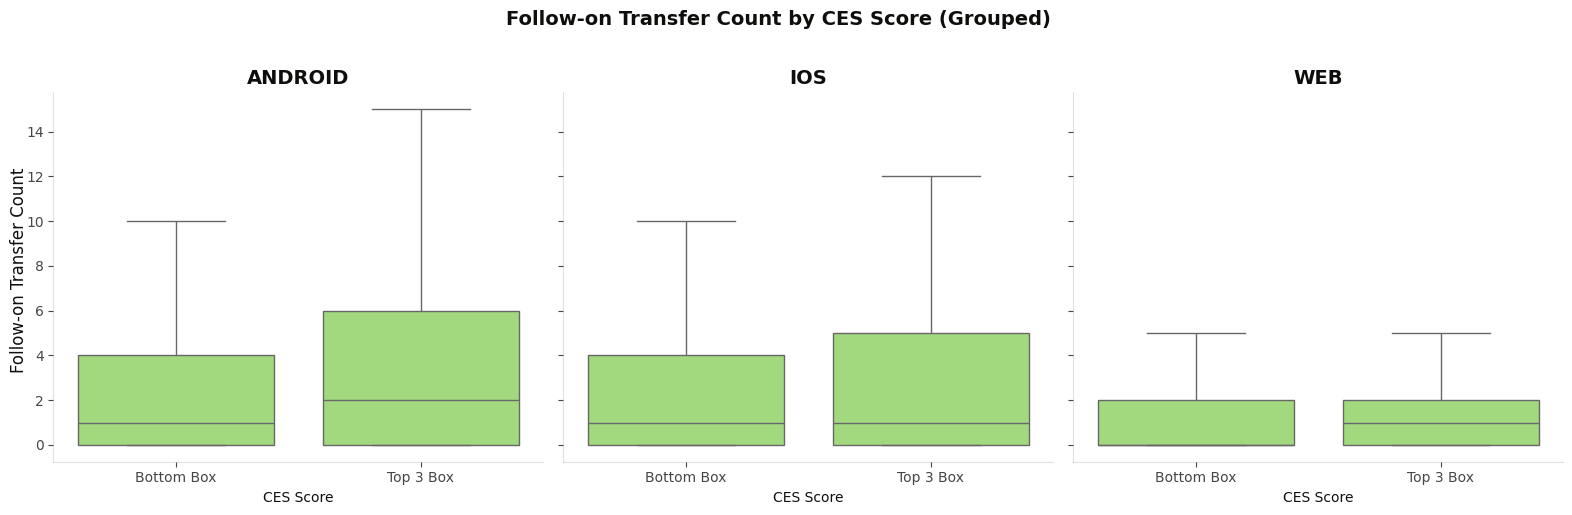

ANDROID: H=16.31, p=0.0001 ***
IOS: H=4.59, p=0.0322 *
WEB: H=29.68, p=0.0000 ***


In [11]:
# Follow-on transfer count = total transfers - 1 by top 3 box
df_followon = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_TOP3', 'FIRST_TRANSFER_AMOUNT_GBP']
)['SEND_COUNT'].sum().reset_index()

df_followon['followon_count'] = df_followon['SEND_COUNT'] - 1

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = df_followon[df_followon['PLATFORM'] == platform]
    
    sns.boxplot(x='CES_TOP3', y='followon_count', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, showfliers=False, order=['Bottom Box', 'Top 3 Box'])
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('')


fig.suptitle('Follow-on Transfer Count by CES Score (Grouped)', fontsize=14, y=1.02)
fig.supylabel('Follow-on Transfer Count')
fig.tight_layout()
plt.show()

from scipy.stats import kruskal

for platform in platforms:
    data = df_followon[df_followon['PLATFORM'] == platform]
    groups = [group['followon_count'].values for _, group in data.groupby('CES_TOP3')]
    stat, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: H={stat:.2f}, p={p:.4f} {sig}")

**Insight:** Follow-on transfer **count** is the strongest behavioral signal for CES. It's significant across all platforms (Android p=0.002, iOS p=0.008, Web p<0.0001). Higher CES users make more repeat transfers. The top/bottom box grouping confirms this (all platforms p<0.05).

**Caveat:** This is the most actionable finding, but causality is unclear — users with stronger underlying intent to use Wise may both rate the experience higher and transact more frequently. Country and platform are confounds (addressed in the regression). That being said, this demonstrates that there may be some downstream economic benefit to Wise from improving verification experiences. We would need properly design experimentation and measurement systems and more data to better understand the true effect and drivers of that effect.

In [12]:
#negative binomial regression to predict follow-on transfer count based on ces score, controlling for platform and country
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_reg = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_SCORE', 'REGISTRATION_COUNTRY']
)['SEND_COUNT'].sum().reset_index()
df_reg['followon_count'] = df_reg['SEND_COUNT'] - 1
df_reg = df_reg[df_reg['followon_count'] >= 0].dropna(subset=['REGISTRATION_COUNTRY'])
country_counts = df_reg['REGISTRATION_COUNTRY'].value_counts()
valid_countries = country_counts[country_counts >= 30].index
df_reg = df_reg[df_reg['REGISTRATION_COUNTRY'].isin(valid_countries)]




model= smf.negativebinomial(
    'followon_count ~ CES_SCORE + C(PLATFORM, Treatment(reference="ANDROID")) + C(REGISTRATION_COUNTRY)',
    data=df_reg
).fit(maxiter=1000)


print(model.summary().tables[1])
print(f"\nCES_SCORE rate ratio: {np.exp(model.params['CES_SCORE']):.3f}")
print(f"CES_SCORE p-value: {model.pvalues['CES_SCORE']:.4f}")



Optimization terminated successfully.
         Current function value: 2.157915
         Iterations: 131
         Function evaluations: 135
         Gradient evaluations: 135
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                              0.8314      0.137      6.086      0.000       0.564       1.099
C(PLATFORM, Treatment(reference="ANDROID"))[T.IOS]     0.0457      0.049      0.941      0.347      -0.049       0.141
C(PLATFORM, Treatment(reference="ANDROID"))[T.WEB]    -0.8021      0.044    -18.043      0.000      -0.889      -0.715
C(REGISTRATION_COUNTRY)[T.BE]                          0.1134      0.244      0.466      0.642      -0.364       0.591
C(REGISTRATION_COUNTRY)[T.BG]                          0.5142      0.226      2.275      0.023       0.071     

**Insight:** After controlling for platform and country, CES score remains a significant predictor of follow-on transfer count (p<0.0001). Each 1-point CES increase is associated with 7.9% more follow-on transfers (rate ratio=1.079). Web users make significantly fewer follow-on transfers than Android (coef=-0.80), while iOS is not significantly different from Android.

**Caveat:** The model controls for observable confounds but cannot establish causation. Unobserved factors (e.g., user's underlying need to send money regularly) could drive both higher CES and higher transfer frequency. The logistic regression on conversion tells a complementary but weaker story (odds ratio=1.026, ~2.6% increase per CES point).

In [13]:
# Logistic regression: does CES score predict conversion, controlling for platform and country?
full_data['converted'] = full_data['FIRST_TRANSFER_DATE'].notna().astype(int)

df_logit = full_data[full_data['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].dropna(subset=['REGISTRATION_COUNTRY'])

country_counts = df_logit['REGISTRATION_COUNTRY'].value_counts()
valid_countries = country_counts[country_counts >= 30].index
df_logit = df_logit[df_logit['REGISTRATION_COUNTRY'].isin(valid_countries)]

logit_model = smf.glm(
    'converted ~ CES_SCORE + C(PLATFORM, Treatment(reference="ANDROID")) + C(REGISTRATION_COUNTRY)',
    data=df_logit,
    family=sm.families.Binomial()
).fit(maxiter=1000)

print(logit_model.summary().tables[1])
print(f"\nCES_SCORE odds ratio: {np.exp(logit_model.params['CES_SCORE']):.3f}")
print(f"CES_SCORE p-value: {logit_model.pvalues['CES_SCORE']:.4f}")


                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                              0.3920      0.084      4.692      0.000       0.228       0.556
C(PLATFORM, Treatment(reference="ANDROID"))[T.IOS]    -0.3644      0.029    -12.543      0.000      -0.421      -0.307
C(PLATFORM, Treatment(reference="ANDROID"))[T.WEB]    -0.7796      0.027    -28.887      0.000      -0.832      -0.727
C(REGISTRATION_COUNTRY)[T.BE]                         -0.4029      0.145     -2.775      0.006      -0.687      -0.118
C(REGISTRATION_COUNTRY)[T.BG]                         -0.1747      0.137     -1.277      0.202      -0.443       0.093
C(REGISTRATION_COUNTRY)[T.CY]                         -0.7413      0.161     -4.604      0.000      -1.057      -0.426
C(REGISTRATION_COUNTRY)[T.CZ]                   

### Full query used for collecting data:

```sql
WITH ces_responses AS (
    -- Web (from INT_FEATURE_FEEDBACK)
    SELECT DISTINCT 
        USER_ID AS user_id,
        SCORE AS ces_score,
        COMMENT AS ces_comment,
        CAST(MESSAGE_TIMESTAMP AS DATE) AS survey_date,
        PLATFORM AS platform,
        'WEB' AS source_table
    FROM ANALYTICS_DB.RPT_PRODUCT.INT_FEATURE_FEEDBACK
    WHERE FEATURE_NAME = 'CONSUMER_ONBOARDING_FLOW_DROP_OFF_CUSTOMER_EFFORT_SCORE'
      AND ADDITIONAL_DROP_OFF_STEP = 'VERIFICATION_FLOW'

    UNION ALL

    -- Mobile (from INT_FEEDBACK_UPDATED)
    SELECT DISTINCT
        USER_ID AS user_id,
        FEEDBACK_SCORE AS ces_score,
        FEEDBACK_COMMENT AS ces_comment,
        CAST(SUBMITTED_AT AS DATE) AS survey_date,
        CLIENT_PLATFORM AS platform,
        'MOBILE' AS source_table
    FROM ANALYTICS_DB.RPT_PRODUCT.INT_FEEDBACK_UPDATED
    WHERE SURVEY = 'CONSUMER_ONBOARDING_FLOW_DROP_OFF_CUSTOMER_EFFORT_SCORE'
      AND FEEDBACK_DROP_OFF_STEP = 'VERIFICATION_FLOW'
      AND FEEDBACK_SCORE IS NOT NULL
),
first_transfer AS (
    SELECT 
        t.USER_ID,
        MIN(t.TRANSFER_CREATION_TIME) AS first_transfer_date,
        MIN_BY(t.INVOICE_VALUE_GBP, t.TRANSFER_CREATION_TIME) AS first_transfer_amount_gbp,
        MIN_BY(t.SOURCE_CURRENCY, t.TRANSFER_CREATION_TIME) AS first_transfer_source_currency,
        MIN_BY(t.INVOICE_VALUE, t.TRANSFER_CREATION_TIME) AS first_transfer_amount_source
    FROM ANALYTICS_DB.RPT_PRODUCT.LOOKUP_TRANSFER_CONTEXT t
    INNER JOIN ces_responses c ON t.USER_ID = c.user_id
    WHERE t.SUCCESSFUL_TRANSFER = TRUE
      AND t.TRANSFER_CREATION_TIME >= c.survey_date
    GROUP BY t.USER_ID
),
monthly_sends AS (
    SELECT 
        t.USER_ID,
        DATE_TRUNC('month', t.TRANSFER_CREATION_TIME)::DATE AS send_month,
        COUNT(*) AS send_count,
        SUM(t.INVOICE_VALUE_GBP) AS send_value_gbp
    FROM ANALYTICS_DB.RPT_PRODUCT.LOOKUP_TRANSFER_CONTEXT t
    INNER JOIN ces_responses c ON t.USER_ID = c.user_id
    WHERE t.SUCCESSFUL_TRANSFER = TRUE
      AND t.TRANSFER_CREATION_TIME >= c.survey_date
    GROUP BY t.USER_ID, DATE_TRUNC('month', t.TRANSFER_CREATION_TIME)::DATE
),
user_country AS (
    SELECT USER_ID, REGISTRATION_COUNTRY
    FROM ANALYTICS_DB.RPT_PRODUCT.ONBOARDING_NEW_USER_CONVERSION
)
SELECT 
    c.user_id,
    c.ces_score,
    c.ces_comment,
    c.survey_date,
    c.platform,
    c.source_table,
    uc.REGISTRATION_COUNTRY,
    f.first_transfer_date,
    f.first_transfer_amount_gbp,
    f.first_transfer_source_currency,
    f.first_transfer_amount_source,
    m.send_month,
    m.send_count,
    m.send_value_gbp
FROM ces_responses c
LEFT JOIN user_country uc ON c.user_id = uc.USER_ID
LEFT JOIN first_transfer f ON c.user_id = f.USER_ID
LEFT JOIN monthly_sends m ON c.user_id = m.USER_ID
ORDER BY c.user_id, m.send_month
```